메모리 기반과 생성기 기반 데이터 로드 비교

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork
import requests
import tarfile

from PIL import Image

In [3]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"
filename = "images-dataSAT.tar"

print("다운로드 시작...")
response = requests.get(url, stream=True)
with open(filename, 'wb') as f:
    f.write(response.content)

print("압축 해제 중...")
with tarfile.open(filename) as tar:
    tar.extractall(path=".")

print("완료!")

다운로드 시작...
압축 해제 중...


C:\Users\Gaten\AppData\Local\Temp\ipykernel_31852\2394331759.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=".")


완료!


In [13]:
# Define directories
extract_dir = "."

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [14]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))


<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg'>


In [15]:
file_name = next(non_agri)
file_name

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6249.jpg'>

In [16]:
os.path.isfile(file_name)

True

In [17]:
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6249.jpg'

In [18]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data

array([[[ 70,  68,  69],
        [ 56,  55,  53],
        [ 49,  43,  43],
        ...,
        [141, 151, 161],
        [ 80,  88,  90],
        [135, 144, 141]],

       [[ 64,  62,  63],
        [ 71,  67,  66],
        [ 81,  76,  73],
        ...,
        [213, 222, 231],
        [101, 109, 111],
        [134, 140, 136]],

       [[ 98,  94,  93],
        [106, 102,  99],
        [113, 108, 105],
        ...,
        [201, 205, 214],
        [107, 111, 112],
        [132, 137, 131]],

       ...,

       [[ 84,  84,  96],
        [ 69,  69,  81],
        [ 63,  62,  80],
        ...,
        [ 15,  24,  19],
        [ 15,  21,  21],
        [ 14,  18,  19]],

       [[ 84,  84,  94],
        [ 61,  61,  71],
        [ 70,  69,  85],
        ...,
        [ 10,  21,  15],
        [ 12,  18,  18],
        [ 12,  16,  17]],

       [[ 88,  88,  96],
        [ 59,  59,  69],
        [ 80,  79,  93],
        ...,
        [  7,  18,  12],
        [  9,  15,  15],
        [ 10,  14,  15]]

In [19]:
print(image_data.shape)

(64, 64, 3)


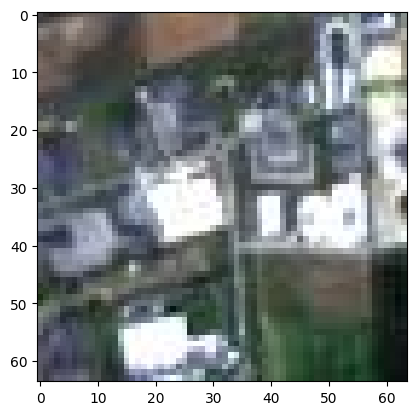

In [20]:
plt.imshow(image_data)

In [21]:
non_agri_images = []
for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri, image_name))
        non_agri_images.append(image_data)
    
non_agri_images = np.array(non_agri_images)

In [22]:
non_agri_images = os.listdir(dir_non_agri)
# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [23]:
non_agri_images.sort()

# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

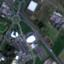

In [24]:
image_data = Image.open(os.path.join(dir_non_agri, non_agri_images[0]))
image_data

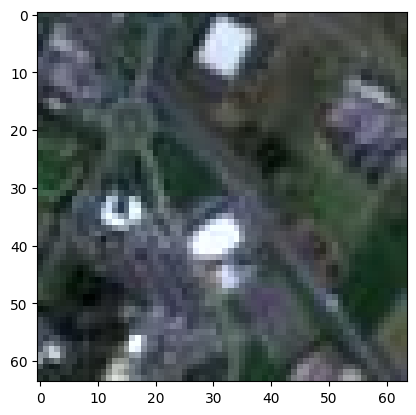

In [25]:
plt.imshow(image_data)

In [26]:
non_agri_images_paths = [os.path.join(dir_non_agri, image) for image in non_agri_images]
#print first five paths
non_agri_images_paths[:5]

['.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [27]:
len(non_agri_images_paths)

3000

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg


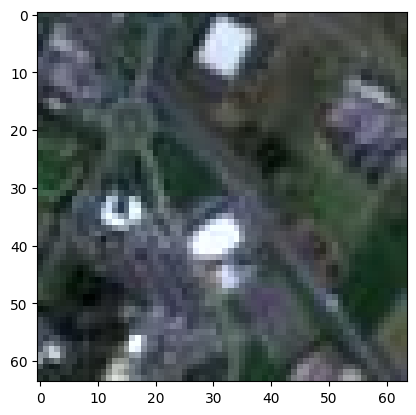

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg


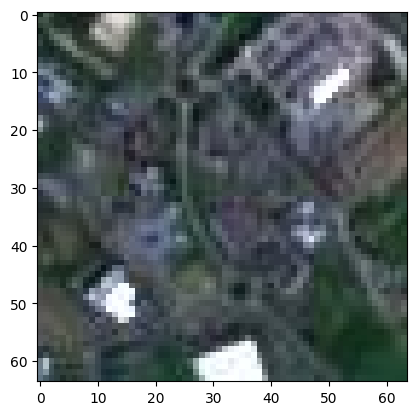

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg


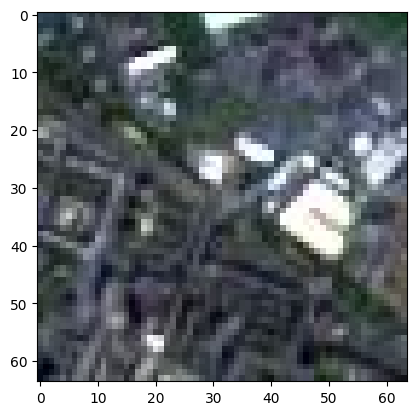

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg


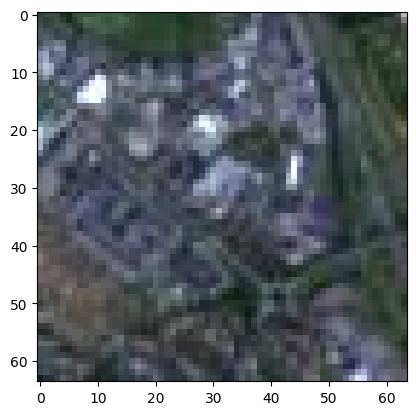

In [28]:
n_images = 4
for image_path in non_agri_images[:n_images]:
    print(image_path)
    image_data = Image.open(os.path.join(dir_non_agri, image_path))
    plt.imshow(image_data)
    plt.show()

In [29]:
agri_images_paths = []
for image in os.listdir(dir_agri):
    agri_images_paths.append(os.path.join(dir_agri, image))

agri_images_paths.sort()

In [30]:
print(len(agri_images_paths))

3000


.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg


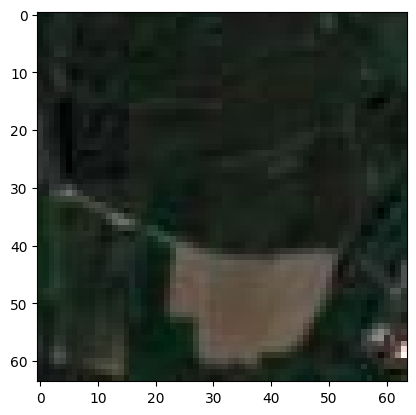

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg


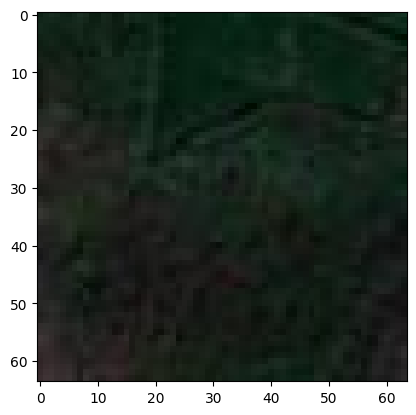

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg


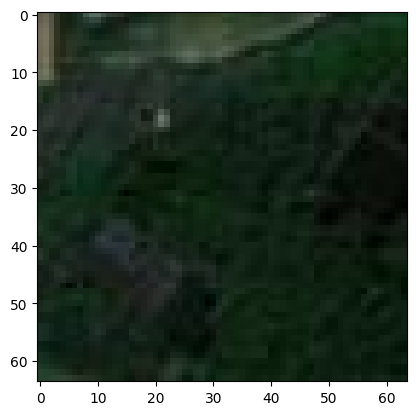

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg


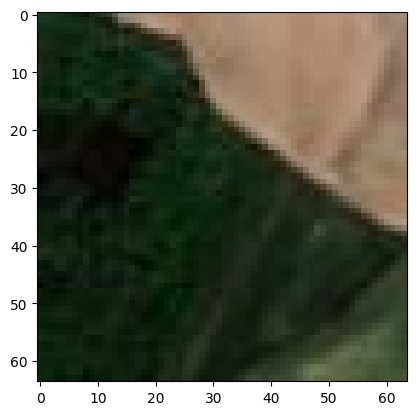

In [31]:
n_images = 4
for image_path in agri_images_paths[:n_images]:
    print(image_path)
    image_data = Image.open(image_path)
    plt.imshow(image_data)
    plt.show()